In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [3]:
df=pd.read_csv('data/house_price_extreme_messy_15654_rows.csv')
df.head()

,House_ID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Owner_Name,...,Email,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Notes
0,H5239,2020/02/21,Bhubaneshwar,1503,1,4,Yes,1981,5.7M,Pooja,...,pooja#gmail.com,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,Suspicious price
1,H2788,2020-11-14,Bhubaneshwar,918,3,1,No,2014,8350753,Rakesh,...,rakesh@outlook.com,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,Suspicious price
2,H5208,29/11/20,Bhubaneshwar,1358,Two,2,N,1995,9.8M,Meena,...,meena@gmail.com,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,Old house
3,H1742,2022/03/21,Cuttack,1085,Three,4,N,2028,5679591,Arun,...,arun@gmail.com,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,Old house
4,H4533,2023/10/25,Bhubaneswar,3292,1,3,No,2028,2054447,Rajesh,...,rajesh@outlook.com,APT,No,1,6,20.2625,86.0394,Rejected,2009594,NaN


In [4]:
colunms=df.columns
colunms

Index(['House_ID', 'Date_Sold', 'City', 'Area_sqft', 'Bedrooms', 'Bathrooms',
       'Garage', 'Year_Built', 'Price', 'Owner_Name', 'Contact', 'Email',
       'Property_Type', 'Furnished', 'Floor_No', 'Total_Floors', 'Latitude',
       'Longitude', 'Loan_Status', 'Registration_Price', 'Notes'],
      dtype='str')

In [5]:
df = df.drop(['House_ID','Owner_Name','Contact','Email','Notes','Latitude',	'Longitude'], axis=1)
df.head()

,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Loan_Status,Registration_Price
0,2020/02/21,Bhubaneshwar,1503,1,4,Yes,1981,5.7M,Flat,N,Ground,5,Approved,13712835
1,2020-11-14,Bhubaneshwar,918,3,1,No,2014,8350753,Apartment,No,2,2,Pending,6663623
2,29/11/20,Bhubaneshwar,1358,Two,2,N,1995,9.8M,Apartment,Y,3,5,Rejected,14044602
3,2022/03/21,Cuttack,1085,Three,4,N,2028,5679591,Flat,N,Ground,2,Pending,10877065
4,2023/10/25,Bhubaneswar,3292,1,3,No,2028,2054447,APT,No,1,6,Rejected,2009594


In [6]:
df['Bedrooms'].unique()
mapping = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
}

df['Bedrooms'] = df['Bedrooms'].replace(mapping)
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
df['Bedrooms'].unique()

array([1, 3, 2, 4])

In [7]:
df['Garage'].unique()
mapping = {
    'Yes': 1,
    'No': 0,
    'Y': 1,
    'N': 0,
    'YES': 1,
}
df['Garage'] = df['Garage'].replace(mapping)
df['Garage'] = pd.to_numeric(df['Garage'], errors='coerce')
df['Garage'].unique()


array([1, 0])

In [8]:
df['Furnished'].unique()
df['Furnished'] = df['Furnished'].replace(mapping)
df['Furnished'] = pd.to_numeric(df['Furnished'], errors='coerce')
df['Furnished'].unique()


array([0, 1])

In [9]:
df['City'].unique()
city_mapping = {
    'Bhubaneshwar': 'Bhubaneswar',
    'BBSR': 'Bhubaneswar'
}
df['City'] = df['City'].replace(city_mapping)
df['City'].unique()

<StringArray>
['Bhubaneswar', 'Cuttack', 'Puri', 'Khordha']
Length: 4, dtype: str

In [10]:
df['Property_Type'].unique()
property_mapping = {
    "APT": "Apartment"
}
df['Property_Type'] = df['Property_Type'].replace(property_mapping)
df['Property_Type'].unique()

<StringArray>
['Flat', 'Apartment', 'House', 'Villa']
Length: 4, dtype: str

In [11]:
df['Floor_No'].unique()
floor_mapping = {
    'Ground': 0,
    'G': 0
}
df['Floor_No'] = df['Floor_No'].replace(floor_mapping)
df['Floor_No'] = pd.to_numeric(df['Floor_No'], errors='coerce')
df['Floor_No'].unique()

array([0, 2, 3, 1])

In [12]:
df['Loan_Status'].unique()

<StringArray>
['Approved', 'Pending', 'Rejected']
Length: 3, dtype: str

In [13]:
# df['Area_sqft'].unique()
# df['Area_sqft'] = pd.to_numeric(df['Area_sqft'], errors='coerce')
# df['Area_sqft']
# remove text
df['Area_sqft'] = df['Area_sqft'].str.replace(' sqft', '', regex=False)

# convert
df['Area_sqft'] = pd.to_numeric(df['Area_sqft'], errors='coerce')

# check missing
print(df['Area_sqft'].isnull().sum())

# fill missing
df['Area_sqft'] = df['Area_sqft'].fillna(df['Area_sqft'].median())
df = df[df['Area_sqft'] > 0]

print(df['Area_sqft'].describe())
print(df['Area_sqft'].nunique())



80
count    15637.000000
mean      2251.381915
std       1004.839812
min        500.000000
25%       1390.000000
50%       2255.000000
75%       3111.000000
max       4000.000000
Name: Area_sqft, dtype: float64
3455


In [14]:
df['Price'].unique()
df['Price'] = df['Price'].str.replace('M', 'e6', regex=False)
df['Price'] = pd.to_numeric(df['Price'])
df['Price']

0         5700000.0
1         8350753.0
2         9800000.0
3         5679591.0
4         2054447.0
            ...    
15649     9100000.0
15650    12639088.0
15651     6806979.0
15652    14400000.0
15653     6474127.0
Name: Price, Length: 15637, dtype: float64

In [15]:
df['Date_Sold']
date1 = pd.to_datetime(df['Date_Sold'], format='%Y-%m-%d', errors='coerce')
date2 = pd.to_datetime(df['Date_Sold'], format='%Y/%m/%d', errors='coerce')
date3 = pd.to_datetime(df['Date_Sold'], format='%d/%m/%y', errors='coerce')
df['Date_Sold'] = date1.fillna(date2).fillna(date3)

df['Date_Sold'].isnull().sum()
df.Date_Sold



0       2020-02-21
1       2020-11-14
2       2020-11-29
3       2022-03-21
4       2023-10-25
           ...    
15649   2022-07-12
15650   2021-11-01
15651   2022-04-30
15652   2020-04-02
15653   2020-06-27
Name: Date_Sold, Length: 15637, dtype: datetime64[us]

In [16]:
df['Sold_Year'] = df['Date_Sold'].dt.year
df['House_Age'] = df['Sold_Year'] - df['Year_Built']
df['House_Age']
df = df[df['House_Age'] >= 0]
df.info()
df=df.drop(['Date_Sold', 'Sold_Year', 'Year_Built'], axis=1)

<class 'pandas.DataFrame'>
Index: 7286 entries, 0 to 15653
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date_Sold           7286 non-null   datetime64[us]
 1   City                7286 non-null   str           
 2   Area_sqft           7286 non-null   float64       
 3   Bedrooms            7286 non-null   int64         
 4   Bathrooms           7286 non-null   int64         
 5   Garage              7286 non-null   int64         
 6   Year_Built          7286 non-null   int64         
 7   Price               7249 non-null   float64       
 8   Property_Type       7286 non-null   str           
 9   Furnished           7286 non-null   int64         
 10  Floor_No            7286 non-null   int64         
 11  Total_Floors        7286 non-null   int64         
 12  Loan_Status         7286 non-null   str           
 13  Registration_Price  7286 non-null   int64         
 14  Sold_Ye

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 7286 entries, 0 to 15653
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   City                7286 non-null   str    
 1   Area_sqft           7286 non-null   float64
 2   Bedrooms            7286 non-null   int64  
 3   Bathrooms           7286 non-null   int64  
 4   Garage              7286 non-null   int64  
 5   Price               7249 non-null   float64
 6   Property_Type       7286 non-null   str    
 7   Furnished           7286 non-null   int64  
 8   Floor_No            7286 non-null   int64  
 9   Total_Floors        7286 non-null   int64  
 10  Loan_Status         7286 non-null   str    
 11  Registration_Price  7286 non-null   int64  
 12  House_Age           7286 non-null   int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 796.9 KB


In [18]:
df.isnull().sum()

City                   0
Area_sqft              0
Bedrooms               0
Bathrooms              0
Garage                 0
Price                 37
Property_Type          0
Furnished              0
Floor_No               0
Total_Floors           0
Loan_Status            0
Registration_Price     0
House_Age              0
dtype: int64

In [19]:
df.isnull().sum()

City                   0
Area_sqft              0
Bedrooms               0
Bathrooms              0
Garage                 0
Price                 37
Property_Type          0
Furnished              0
Floor_No               0
Total_Floors           0
Loan_Status            0
Registration_Price     0
House_Age              0
dtype: int64

In [20]:
df = df.dropna(subset=['Price'])
# df=df.drop('Date_Sold', axis=1)


In [21]:
df.head()

,City,Area_sqft,Bedrooms,Bathrooms,Garage,Price,Property_Type,Furnished,Floor_No,Total_Floors,Loan_Status,Registration_Price,House_Age
0,Bhubaneswar,1503.0,1,4,1,5700000.0,Flat,0,0,5,Approved,13712835,39
1,Bhubaneswar,918.0,3,1,0,8350753.0,Apartment,0,2,2,Pending,6663623,6
2,Bhubaneswar,1358.0,2,2,0,9800000.0,Apartment,1,3,5,Rejected,14044602,25
5,Bhubaneswar,3906.0,1,1,0,4200000.0,Flat,0,0,5,Pending,9350099,36
6,Bhubaneswar,1884.0,1,1,1,7543670.0,House,0,1,13,Approved,3626229,37


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 7249 entries, 0 to 15653
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   City                7249 non-null   str    
 1   Area_sqft           7249 non-null   float64
 2   Bedrooms            7249 non-null   int64  
 3   Bathrooms           7249 non-null   int64  
 4   Garage              7249 non-null   int64  
 5   Price               7249 non-null   float64
 6   Property_Type       7249 non-null   str    
 7   Furnished           7249 non-null   int64  
 8   Floor_No            7249 non-null   int64  
 9   Total_Floors        7249 non-null   int64  
 10  Loan_Status         7249 non-null   str    
 11  Registration_Price  7249 non-null   int64  
 12  House_Age           7249 non-null   int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 792.9 KB


In [23]:
df.isnull().sum()
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price                 1.000000
Floor_No              0.011813
Bedrooms              0.004703
Garage               -0.001168
Furnished            -0.004386
Registration_Price   -0.004914
House_Age            -0.008021
Area_sqft            -0.013295
Bathrooms            -0.014454
Total_Floors         -0.018243
Name: Price, dtype: float64

In [24]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print(df['Price'].describe())
print(df['Price'].nunique())

count    7.238000e+03
mean     8.486876e+06
std      3.758176e+06
min      2.000000e+06
25%      5.200000e+06
50%      8.500000e+06
75%      1.174986e+07
max      1.500000e+07
Name: Price, dtype: float64
5539


In [25]:
y = df['Price']
x = df.drop(['Price', 'Loan_Status'], axis=1)

In [26]:
x = pd.get_dummies(x, drop_first=True)
x.head()


,Area_sqft,Bedrooms,Bathrooms,Garage,Furnished,Floor_No,Total_Floors,Registration_Price,House_Age,City_Cuttack,City_Khordha,City_Puri,Property_Type_Flat,Property_Type_House,Property_Type_Villa
0,1503.0,1,4,1,0,0,5,13712835,39,False,False,False,True,False,False
1,918.0,3,1,0,0,2,2,6663623,6,False,False,False,False,False,False
2,1358.0,2,2,0,1,3,5,14044602,25,False,False,False,False,False,False
5,3906.0,1,1,0,0,0,5,9350099,36,False,False,False,True,False,False
6,1884.0,1,1,1,0,1,13,3626229,37,False,False,False,False,True,False


In [27]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(xtrain, ytrain)

ypred = model.predict(xtest)
print('training score:', model.score(xtrain, ytrain))
print('testing score:', model.score(xtest, ytest))

print("R2 Score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))

training score: 0.26586236874770475
testing score: -0.00816168889228086
R2 Score: -0.00816168889228086
MAE: 3309154.5700464733


In [29]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(xtrain, ytrain)

print(model.score(xtrain, ytrain))
print(model.score(xtest, ytest))

0.08562835269452318
-0.016641932494791956


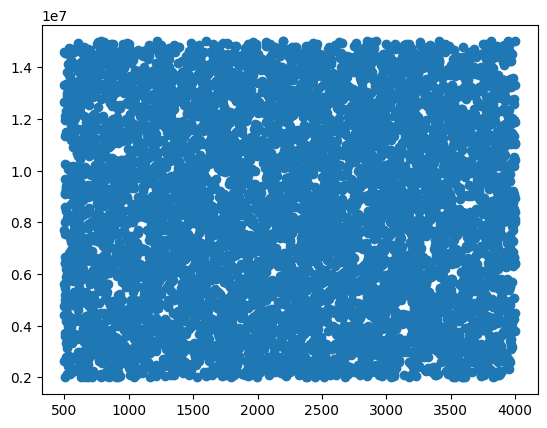

In [30]:
import matplotlib.pyplot as plt
plt.scatter(df['Area_sqft'], df['Price'])
plt.show()

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(xtrain, ytrain)

print("Train R2:", lr.score(xtrain, ytrain))
print("Test R2:", lr.score(xtest, ytest))

Train R2: 0.0026183108869606286
Test R2: -0.001349477138394839


In [32]:
df['Price_Category'] = pd.qcut(
    df['Price'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
df['Price_Category'].value_counts()

Price_Category
Low       2413
High      2413
Medium    2412
Name: count, dtype: int64

In [33]:
y = df['Price_Category']
X = df.drop(['Price', 'Price_Category', 'Loan_Status'], axis=1)

X = pd.get_dummies(X, drop_first=True)

In [34]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=20,
    random_state=42
)

clf.fit(xtrain, ytrain)

ypred = clf.predict(xtest)

print("Training Accuracy:", clf.score(xtrain, ytrain))
print("Testing Accuracy:", clf.score(xtest, ytest))

Training Accuracy: 0.6373864982234505
Testing Accuracy: 0.3324125230202578
